# Stadteil konstruieren

In [84]:
import geopandas as gpd
import pandas as pd

PATH_RAW = "../data/raw/"

In [85]:
gdf_stadtteile = gpd.read_file(PATH_RAW + "raw_data_geoportal/app_stadtteile_EPSG_4326.json")

In [86]:
gdf_stadtteile.head()

,id,bezirk,bezirk_name,stadtteil_name,stadtteil_schluessel,stadtteil_nummer,geometry
0,APP_STADTTEILE_1,1,Hamburg-Mitte,Hamburg-Altstadt,02101,101,"MULTIPOLYGON (((10.00603 53.5485, 10.00704 53...."
1,APP_STADTTEILE_2,1,Hamburg-Mitte,HafenCity,02102,102,"MULTIPOLYGON (((9.99864 53.53696, 9.99737 53.5..."
2,APP_STADTTEILE_3,1,Hamburg-Mitte,Neustadt,02103,103,"MULTIPOLYGON (((9.99383 53.55239, 9.99213 53.5..."
3,APP_STADTTEILE_4,1,Hamburg-Mitte,St. Pauli,02104,104,"MULTIPOLYGON (((9.96336 53.54434, 9.96233 53.5..."
4,APP_STADTTEILE_5,1,Hamburg-Mitte,St. Georg,02105,105,"MULTIPOLYGON (((10.0123 53.54985, 10.0121 53.5..."


In [87]:
print(gdf_stadtteile["stadtteil_name"].unique())

<StringArray>
[  'Hamburg-Altstadt',          'HafenCity',           'Neustadt',
          'St. Pauli',          'St. Georg',        'Hammerbrook',
          'Borgfelde',               'Hamm',               'Horn',
          'Billstedt',
 ...
          'Marmstorf',          'Eißendorf',           'Heimfeld',
           'Moorburg',        'Altenwerder',          'Hausbruch',
 'Neugraben-Fischbek',            'Francop',         'Neuenfelde',
              'Cranz']
Length: 104, dtype: str


In [88]:
gdf_stadtteile.to_file(
    "../data/prep/hamburg_districts.geojson",
    driver="GeoJSON"
)

# Barmbek Süd rausfiltern

In [89]:
barmbek_poly = gdf_stadtteile[
    gdf_stadtteile["stadtteil_name"] == "Barmbek-Süd"
]

In [90]:
barmbek_poly.head()

,id,bezirk,bezirk_name,stadtteil_name,stadtteil_schluessel,stadtteil_nummer,geometry
49,APP_STADTTEILE_50,4,Hamburg-Nord,Barmbek-Süd,02408,408,"MULTIPOLYGON (((10.035 53.57253, 10.03493 53.5..."


In [91]:
barmbek_poly.to_file(
    "../data/prep/barmbek_sued.geojson",
    driver="GeoJSON"
)

# Vergleichsstadtteil rausfiltern: Harvestehude

In [92]:
harvestehude_poly = gdf_stadtteile[
    gdf_stadtteile["stadtteil_name"] == "Harvestehude"
]

In [93]:
harvestehude_poly.to_file(
    "../data/prep/harvestehude.geojson",
    driver="GeoJSON"
)

In [94]:
import pandas as pd

# =========================
# 1. LOAD
# =========================
df = pd.read_excel(
    "../data/raw/raw_data_population/Stadtteilprofile2024.xlsx",
    header=[0,1]
)

# =========================
# 2. FLATTEN COLUMNS
# =========================
df.columns = [
    "_".join([str(c) for c in col if c]) 
    for col in df.columns
]

# =========================
# 3. REMOVE FAKE HEADER ROW
# =========================
df = df.iloc[1:].copy()

# =========================
# 4. RENAME STADTTEIL COLUMN
# =========================
df = df.rename(columns={
    "Stadtgebiet_Unnamed: 0_level_1": "district_name"
})

# =========================
# 5. CLEAN
# =========================
df = df.reset_index(drop=True)

# =========================
# 6. FILTER HARVESTEHUDE
# =========================
df_harvestehude = df[
    df["district_name"] == "Harvestehude"
].copy()

# =========================
# 7. CHECK
# =========================
print(df_harvestehude.head())
print(df_harvestehude.shape)

   district_name Bevölkerung und Haushalte 31.12.2024_Bevölkerung  \
32  Harvestehude                                            17962   

   Bevölkerung und Haushalte 31.12.2024_Unter 18-Jährige  \
32                                               2636      

   Bevölkerung und Haushalte 31.12.2024_Anteil der unter 18-Jährigen in %  \
32                                               14.7                       

   Bevölkerung und Haushalte 31.12.2024_ 65-Jährige und Ältere  \
32                                               3848            

   Bevölkerung und Haushalte 31.12.2024_Anteil der 65-Jährigen und Älteren in %  \
32                                               21.4                             

   Bevölkerung und Haushalte 31.12.2024_Ausländer: innen  \
32                                               2610      

   Bevölkerung und Haushalte 31.12.2024_Anteil der Ausländer: innen in %  \
32                                               14.5                      

   Bevölker

In [95]:
for col in df_harvestehude.columns:
    print(col)

district_name
Bevölkerung und Haushalte 31.12.2024_Bevölkerung
Bevölkerung und Haushalte 31.12.2024_Unter 18-Jährige
Bevölkerung und Haushalte 31.12.2024_Anteil der unter 18-Jährigen in %
Bevölkerung und Haushalte 31.12.2024_ 65-Jährige und Ältere
Bevölkerung und Haushalte 31.12.2024_Anteil der 65-Jährigen und Älteren in %
Bevölkerung und Haushalte 31.12.2024_Ausländer: innen
Bevölkerung und Haushalte 31.12.2024_Anteil der Ausländer: innen in %
Bevölkerung und Haushalte 31.12.2024_Bevölkerung mit Migrations-hintergrund
Bevölkerung und Haushalte 31.12.2024_Anteil der Bevölkerung mit Migrations-hintergrund in %
Bevölkerung und Haushalte 31.12.2024_Unter 18-Jährige mit Migrations-hintergrund
Bevölkerung und Haushalte 31.12.2024_Anteil der unter 18-Jährigen mit Migrations-hintergrund in %
Bevölkerung und Haushalte 31.12.2024_Haushalte
Bevölkerung und Haushalte 31.12.2024_Personen je Haushalt
Bevölkerung und Haushalte 31.12.2024_Einpersonen-haushalte
Bevölkerung und Haushalte 31.12.2024_Ant

# Harvestehude households

In [96]:
# =========================
# HOUSEHOLDS HARVESTEHUDE
# =========================

df_hh = df_harvestehude.copy()

# Rename (JETZT KORREKT!)
df_hh = df_hh.rename(columns={
    "Bevölkerung und Haushalte 31.12.2024_Anteil der Einpersonen-haushalte in %": "single_pct",
    "Bevölkerung und Haushalte 31.12.2024_Anteil der Haushalte mit Kindern in %": "children_pct"
})

# Year hinzufügen (weil du kein Jahr-Feld hast!)
df_hh["year"] = 2024

# Clean (eigentlich schon Zahlen, aber sicher ist sicher)
df_hh["single_pct"] = df_hh["single_pct"].astype(float)
df_hh["children_pct"] = df_hh["children_pct"].astype(float)

# Other berechnen
df_hh["other_pct"] = 100 - df_hh["single_pct"] - df_hh["children_pct"]

# District
df_hh["district"] = "Harvestehude"

# Long format
df_hh_long = df_hh.melt(
    id_vars=["year", "district"],
    value_vars=["single_pct", "children_pct", "other_pct"],
    var_name="group",
    value_name="value"
)

# Labels
df_hh_long["group"] = df_hh_long["group"].replace({
    "single_pct": "Single households",
    "children_pct": "Households with children",
    "other_pct": "Other households"
})

# Export
df_hh_long.to_csv(
    "../data/mart/mart_households_harvestehude.csv",
    index=False
)

print(df_hh_long)

   year      district                     group  value
0  2024  Harvestehude         Single households   59.8
1  2024  Harvestehude  Households with children   14.6
2  2024  Harvestehude          Other households   25.6


# Harvestehude Car ownership

In [97]:
# =========================
# CAR OWNERSHIP HARVESTEHUDE
# =========================

df_car = df_harvestehude.copy()

# Rename
df_car = df_car.rename(columns={
    "Infrastruktur und Verkehr_PKW-Dichte (Jan 2025)": "cars_per_1000"
})

# In Prozent umrechnen
df_car["car_owner_pct"] = df_car["cars_per_1000"].astype(float) / 10
df_car["no_car_pct"] = 100 - df_car["car_owner_pct"]

# Year + District
df_car["year"] = 2024
df_car["district"] = "Harvestehude"

# Long format
df_car_long = df_car.melt(
    id_vars=["year", "district"],
    value_vars=["car_owner_pct", "no_car_pct"],
    var_name="group",
    value_name="value"
)

# Labels
df_car_long["group"] = df_car_long["group"].replace({
    "car_owner_pct": "Car owners",
    "no_car_pct": "No car"
})

# Export
df_car_long.to_csv(
    "../data/mart/mart_car_harvestehude.csv",
    index=False
)

print(df_car_long)

   year      district       group  value
0  2024  Harvestehude  Car owners   36.8
1  2024  Harvestehude      No car   63.2


# Harvestehude Migration

In [98]:
# =========================
# MIGRATION HARVESTEHUDE
# =========================

df_mig = df_harvestehude.copy()

# Rename
df_mig = df_mig.rename(columns={
    "Bevölkerung und Haushalte 31.12.2024_Anteil der Bevölkerung mit Migrations-hintergrund in %": "migration_pct"
})

# Clean
df_mig["migration_pct"] = df_mig["migration_pct"].astype(float)

# Rest
df_mig["no_migration_pct"] = 100 - df_mig["migration_pct"]

# Year + District
df_mig["year"] = 2024
df_mig["district"] = "Harvestehude"

# Long format
df_mig_long = df_mig.melt(
    id_vars=["year", "district"],
    value_vars=["migration_pct", "no_migration_pct"],
    var_name="group",
    value_name="value"
)

# Labels
df_mig_long["group"] = df_mig_long["group"].replace({
    "migration_pct": "With migration background",
    "no_migration_pct": "Without migration background"
})

# Export
df_mig_long.to_csv(
    "../data/mart/mart_migration_harvestehude.csv",
    index=False
)

print(df_mig_long)

   year      district                         group  value
0  2024  Harvestehude     With migration background   29.6
1  2024  Harvestehude  Without migration background   70.4


# Harvestehide avaibility

In [99]:
# =========================
# INFRASTRUCTURE HARVESTEHUDE
# =========================

df_inf = df_harvestehude.copy()

# Rename (wichtig: lange Namen kürzen)
df_inf = df_inf.rename(columns={
    "Infrastruktur und Verkehr_Kindertageseinrichtungen (März 2025)": "kitas",
    "Infrastruktur und Verkehr_Grundschulen (2024/2025)": "primary_schools",
    "Infrastruktur und Verkehr_Schüler:innen der Sekundar-stufe I (2024/2025)": "students_secondary",
    "Infrastruktur und Verkehr_Anteil der Schüler:innen in Stadtteil-schulen in % (2024/2025)": "district_school_pct",
    "Infrastruktur und Verkehr_Anteil der Schüler:innen in Gymnasien in % (2024/2025)": "gymnasium_pct",
    "Infrastruktur und Verkehr_Nieder-gelassene Ärztinnen/Ärzte (Jan 2025)": "doctors",
    "Infrastruktur und Verkehr_Allgemein-ärztinnen/-ärzte (Jan 2025)": "general_doctors",
    "Infrastruktur und Verkehr_Zahn-ärztinnen/-ärzte (Dez 2024)": "dentists",
    "Infrastruktur und Verkehr_Apotheken (Dez 2024)": "pharmacies"
})

# Year + District
df_inf["year"] = 2024
df_inf["district"] = "Harvestehude"

# Auswahl (nur relevante Spalten)
df_inf = df_inf[[
    "year", "district",
    "kitas", "primary_schools", "students_secondary",
    "district_school_pct", "gymnasium_pct",
    "doctors", "general_doctors", "dentists", "pharmacies"
]]

# Long format
df_inf_long = df_inf.melt(
    id_vars=["year", "district"],
    var_name="indicator",
    value_name="value"
)

# Export
df_inf_long.to_csv(
    "../data/mart/mart_infrastructure_harvestehude.csv",
    index=False
)

print(df_inf_long)

   year      district            indicator value
0  2024  Harvestehude                kitas    15
1  2024  Harvestehude      primary_schools     0
2  2024  Harvestehude   students_secondary   778
3  2024  Harvestehude  district_school_pct  16.6
4  2024  Harvestehude        gymnasium_pct  80.8
5  2024  Harvestehude              doctors   145
6  2024  Harvestehude      general_doctors    18
7  2024  Harvestehude             dentists    46
8  2024  Harvestehude           pharmacies     3


# Barmbek Süd als Polygamie

In [100]:
import geopandas as gpd

# Kopie erstellen (wichtig!)
barmbek_area = barmbek_poly.copy()

# In metrisches CRS
barmbek_area = barmbek_area.to_crs(epsg=25832)

# Fläche berechnen
barmbek_area["area_km2"] = barmbek_area.geometry.area / 1_000_000

# Optional: wieder zurück zu WGS84 für Tableau
barmbek_area = barmbek_area.to_crs(epsg=4326)

# Export NEUE Datei
barmbek_area.to_file(
    "../data/prep/prep_barmbek_area.geojson",
    driver="GeoJSON"
)

# Check
print(barmbek_area[["area_km2"]])

    area_km2
49  3.089634


# Erstellen DATEN FÜR PREP 
* in Format GEojson
* auf Barmbek zugeschnitten

# LSA Lichtschaltanlagen Barmbek

In [101]:
import pandas as pd
import geopandas as gpd

PATH_RAW = "../data/raw/"

df_lsa = pd.read_csv(
    PATH_RAW + "raw_data_geoportal/app_lsa_knotengrunddaten_EPSG_4326.csv",
    sep=";"
)

# prüfen wie die Geometry-Spalte heißt
print(df_lsa.columns)

Index(['_fid', 'knoten', 'art', 'LSA_Name', 'geom',
       'coordinate_reference_system'],
      dtype='str')


In [102]:
print(df_lsa.columns)
print(df_lsa.head())

Index(['_fid', 'knoten', 'art', 'LSA_Name', 'geom',
       'coordinate_reference_system'],
      dtype='str')
                             _fid  knoten         art  \
0  APP_LSA_KNOTENGRUNDDATEN_15667       2  K-LSA        
1  APP_LSA_KNOTENGRUNDDATEN_15668       3  K-LSA        
2  APP_LSA_KNOTENGRUNDDATEN_15669       5  K-LSA        
3  APP_LSA_KNOTENGRUNDDATEN_15670       7  K-LSA        
4  APP_LSA_KNOTENGRUNDDATEN_15671       8  K-LSA        

                                   LSA_Name                              geom  \
0  Osterstraße/Eppendorfer Weg                MULTIPOINT (9.961461 53.573879)   
1  Hoheluftchaussee/Eppendorfer Weg           MULTIPOINT (9.972077 53.582005)   
2  Lübecker Straße/Mühlendamm                MULTIPOINT (10.025834 53.558859)   
3  Stresemannstraße/Kieler Straße             MULTIPOINT (9.945320 53.562946)   
4  Elbchaussee/Sieberlingstraße               MULTIPOINT (9.844531 53.550471)   

  coordinate_reference_system  
0                   EPSG:432

In [103]:
gdf_lsa = gpd.GeoDataFrame(
    df_lsa,
    geometry=gpd.GeoSeries.from_wkt(df_lsa['geom']),
    crs="EPSG:4326"
)

1740


<Axes: >

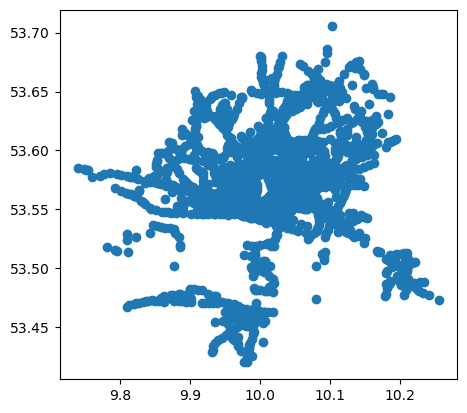

In [104]:
print(len(gdf_lsa))
gdf_lsa.plot()

In [105]:
gdf_lsa = gdf_lsa.cx[9.95:10.1, 53.55:53.60]

In [106]:
def filter_barmbek(gdf):
    return gpd.clip(gdf, barmbek_poly)

In [107]:
gdf_lsa_barmbek = filter_barmbek(gdf_lsa)

In [108]:
gdf_lsa_barmbek.to_file(
    "../data/prep/prep_lsa_barmbek.geojson",
    driver="GeoJSON"
)

# HVV Switch Points

In [109]:
import geopandas as gpd

PATH_RAW = "../data/raw/"

gdf_switch = gpd.read_file(
    PATH_RAW + "raw_data_mobility/de_hh_up_switch_punkte_api_EPSG_4326.json"
)

print(gdf_switch.head())
print(gdf_switch.crs)

                             id             bezeichnung  \
0  DE.HH.UP_SWITCH_PUNKTE_API_1  Hbf. Glockengießerwall   
1  DE.HH.UP_SWITCH_PUNKTE_API_2            Berliner Tor   
2  DE.HH.UP_SWITCH_PUNKTE_API_3          Wandsbek Markt   
3  DE.HH.UP_SWITCH_PUNKTE_API_4          Saarlandstraße   
4  DE.HH.UP_SWITCH_PUNKTE_API_5      Kellinghusenstraße   

                                   adresse einrichtung_quartal  inbetrieb  \
0  ggü. Glockengießerwall 3, 20095 Hamburg     4. Quartal 2016       True   
1        Beim Strohhause 38, 20099 Hamburg     2. Quartal 2013       True   
2           Schloßstraße 38, 22041 Hamburg     2. Quartal 2014       True   
3         Saarlandstraße 39, 22303 Hamburg     1. Quartal 2015       True   
4      ggü. Goernestraße 21, 20249 Hamburg     4. Quartal 2014       True   

   stellplaetze  ladesaeulen  ladepunkte  sixt  miles  free2move  cambio  \
0          10.0            0           0  True   True       True       2   
1          18.0            9  

In [110]:
gdf_switch_barmbek = gpd.clip(gdf_switch, barmbek_poly)

In [111]:
gdf_switch_barmbek.to_file(
    "../data/prep/switch_barmbek.geojson",
    driver="GeoJSON"
)

# Emobility

In [114]:

import pandas as pd

df_emobility = pd.read_csv(
    PATH_RAW + "raw_data_geoportal/app_stromnetz_emobility_EPSG_4326.csv",
    sep=";"
)



In [115]:
gdf_emobility = gpd.GeoDataFrame(
    gdf_emobility,
    geometry=gpd.GeoSeries.from_wkt(gdf_emobility["the_geom"]),
    crs="EPSG:4326"
)

<Axes: >

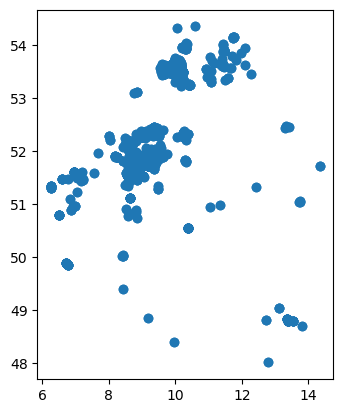

In [116]:
gdf_emobility.plot()

In [117]:
gdf_emobility_barmbek = gpd.clip(gdf_emobility, barmbek_poly)

In [118]:
gdf_emobility_barmbek = gdf_emobility_barmbek.drop_duplicates(
    subset=["standort", "geometry"]
)

In [119]:
print(gdf_emobility_barmbek.crs)

EPSG:4326


In [120]:
gdf_emobility_barmbek.to_file(
    "../data/prep/prep_emobility_barmbek.geojson",
    driver="GeoJSON"
)

# Scooter in Barmbek-Süd

In [121]:
df_scooter = pd.read_csv(
    PATH_RAW + "raw_data_geoportal/de_hh_up_abstellflaechen_e_scooter_EPSG_4326.csv",
    sep=";",
    engine="python"
)

In [122]:
print(df_scooter.columns)
df_scooter.head()

Index(['_fid', 'id', 'bezirk', 'hausnummer', 'strasse', 'geom',
       'coordinate_reference_system'],
      dtype='str')


,_fid,id,bezirk,hausnummer,strasse,geom,coordinate_reference_system
0,DE.HH.UP_ABSTELLFLAECHEN_E_SCOOTER_27,NaN,Harburg,NaN,Hannoversche Straße,POINT (9.989920 53.456314),EPSG:4326
1,DE.HH.UP_ABSTELLFLAECHEN_E_SCOOTER_1,NaN,Altona,NaN,Lagerstraße,POINT (9.967028 53.562444),EPSG:4326
2,DE.HH.UP_ABSTELLFLAECHEN_E_SCOOTER_5,NaN,Altona,NaN,Schanzenstraße,POINT (9.964471 53.558195),EPSG:4326
3,DE.HH.UP_ABSTELLFLAECHEN_E_SCOOTER_6,NaN,Eimsbüttel,NaN,Schulterblatt,POINT (9.960489 53.563566),EPSG:4326
4,DE.HH.UP_ABSTELLFLAECHEN_E_SCOOTER_7,NaN,Altona,NaN,Sternschanze,POINT (9.969391 53.564345),EPSG:4326


In [123]:
gdf_scooter = gpd.GeoDataFrame(
    df_scooter,
    geometry=gpd.GeoSeries.from_wkt(df_scooter["geom"]),
    crs="EPSG:4326"
)

<Axes: >

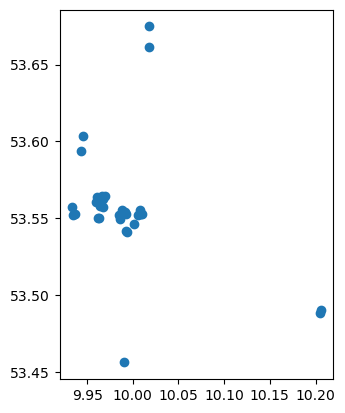

In [124]:
gdf_scooter.plot()

In [125]:
gdf_scooter_barmbek = gpd.clip(
    gdf_scooter,
    barmbek_poly
)

In [126]:
gdf_scooter_barmbek.head()

,_fid,id,bezirk,hausnummer,strasse,geom,coordinate_reference_system,geometry


In [127]:
print(gdf_scooter_barmbek.total_bounds)

[nan nan nan nan]


0


ValueError: aspect must be finite and positive 

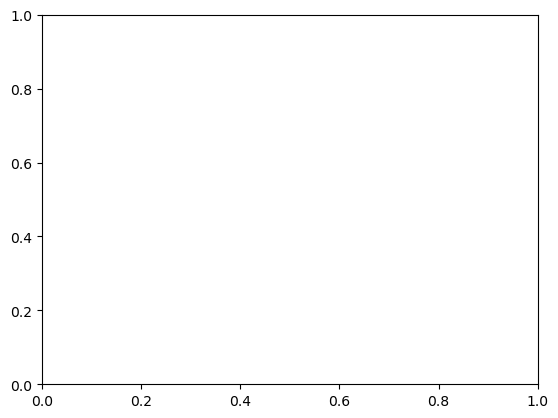

In [128]:
print(len(gdf_scooter_barmbek))
gdf_scooter_barmbek.plot()

# Keine Scooter in Barmbek Süd!

# Kreuzungen in Barmbek Süd

In [129]:
df_cross = pd.read_csv(
    PATH_RAW + "raw_data_geoportal/de_hh_up_fussgaengerueberwege_EPSG_4326.csv",
    sep=";",
    engine="python"
)

In [130]:
print(df_cross.columns)
df_cross.head()

Index(['_fid', 'vz_nr', 'bezeichnung', 'strassenschluessel', 'strassenname',
       'koordinaten', 'quelle', 'erfassungsdatum', 'bemerkung', 'geom',
       'coordinate_reference_system'],
      dtype='str')


,_fid,vz_nr,bezeichnung,strassenschluessel,strassenname,koordinaten,quelle,erfassungsdatum,bemerkung,geom,coordinate_reference_system
0,DE.HH.UP_FUSSGAENGERUEBERWEGE_200012,293,Fußgängerüberweg,C029,Christian-Förster-Straße,"563803.871, 5937552.319",CycloMedia,2023-10-23,NaN,POINT (9.963775 53.582935),EPSG:4326
1,DE.HH.UP_FUSSGAENGERUEBERWEGE_200013,293,Fußgängerüberweg,W249,Wiesingerweg,"563637.82, 5937606.37",CycloMedia,2023-10-23,NaN,POINT (9.961278 53.583441),EPSG:4326
2,DE.HH.UP_FUSSGAENGERUEBERWEGE_200014,293,Fußgängerüberweg,T198,Troplowitzstraße,"564103.543, 5937892.346",CycloMedia,2023-10-23,NaN,POINT (9.968370 53.585955),EPSG:4326
3,DE.HH.UP_FUSSGAENGERUEBERWEGE_200015,293,Fußgängerüberweg,B103,Baumacker,"559383.483, 5941156.007",CycloMedia,2023-09-19,NaN,POINT (9.897699 53.615842),EPSG:4326
4,DE.HH.UP_FUSSGAENGERUEBERWEGE_200016,293,Fußgängerüberweg,M032,Mansteinstraße,"564184.243, 5936861.561",CycloMedia,2023-10-18,NaN,POINT (9.969377 53.576681),EPSG:4326


In [131]:
gdf_cross = gpd.GeoDataFrame(
    df_cross,
    geometry=gpd.GeoSeries.from_wkt(df_cross["geom"]),
    crs="EPSG:4326"
)

1254


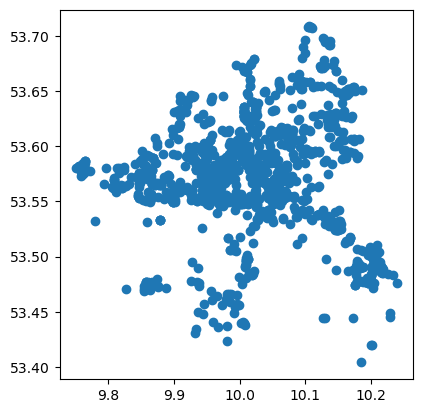

In [132]:
gdf_cross.plot()
print(len(gdf_cross))

In [133]:
gdf_cross_barmbek = gpd.clip(
    gdf_cross,
    barmbek_poly
)

15


<Axes: >

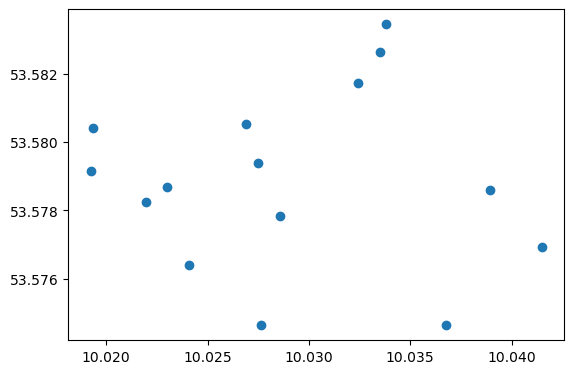

In [134]:
print(len(gdf_cross_barmbek))
gdf_cross_barmbek.plot()

In [135]:
gdf_cross_barmbek.to_file(
    "../data/prep/prep_crossings_barmbek.geojson",
    driver="GeoJSON"
)

# Stadtradstationen in Barmbek Süd

In [136]:
df_stadtrad = pd.read_csv(
    PATH_RAW + "raw_data_geoportal/de_hh_up_stadtrad_stationen_EPSG_4326.csv",
    sep=";",
    engine="python"
)

In [137]:
print(df_stadtrad.columns)
df_stadtrad.head()

Index(['_fid', 'anzahl_raeder', 'uid', 'name', 'stand', 'anzahl_pedelec',
       'anzahl_bike', 'anzahl_cargobike_electric', 'art_der_station',
       'anzahl_scooter', 'anzahl_cargobike', 'anzahl_scooter_electric', 'geom',
       'coordinate_reference_system'],
      dtype='str')


,_fid,anzahl_raeder,uid,name,stand,anzahl_pedelec,anzahl_bike,anzahl_cargobike_electric,art_der_station,anzahl_scooter,anzahl_cargobike,anzahl_scooter_electric,geom,coordinate_reference_system
0,DE.HH.UP_STADTRAD_STATIONEN_117742230,0,a0fc2a81-960f-4f28-9f7b-9220e54bc439,Enckeplatz / Hütten,2.025072e+13,0,0,0,bike,NaN,NaN,NaN,POINT (9.976955 53.552446),EPSG:4326
1,DE.HH.UP_STADTRAD_STATIONEN_117742231,1,698a806c-29a2-403d-9c9d-63444108f7c9,U Steinstraße / Deichtorplatz,2.025072e+13,0,1,0,bike,NaN,NaN,NaN,POINT (10.004393 53.548597),EPSG:4326
2,DE.HH.UP_STADTRAD_STATIONEN_117742232,14,03d14e9c-c624-4470-81fe-6e5ec8b2369f,Am Strandkai / Großer Grasbrook,2.025072e+13,0,14,0,bike,NaN,NaN,NaN,POINT (9.993763 53.539543),EPSG:4326
3,DE.HH.UP_STADTRAD_STATIONEN_117742233,1,bd4668f5-f78c-4833-8f2c-244ecc67749b,U Überseequartier / Grasbrookpark,2.025072e+13,0,1,0,bike,NaN,NaN,NaN,POINT (9.996601 53.540229),EPSG:4326
4,DE.HH.UP_STADTRAD_STATIONEN_117742234,11,d423adc0-e08c-4264-be81-38b054f6ed60,Osakaallee / Überseequartier,2.025072e+13,0,11,0,bike,NaN,NaN,NaN,POINT (9.999778 53.541480),EPSG:4326


In [138]:
gdf_stadtrad = gpd.GeoDataFrame(
    df_stadtrad,
    geometry=gpd.GeoSeries.from_wkt(df_stadtrad["geom"]),
    crs="EPSG:4326"
)

334


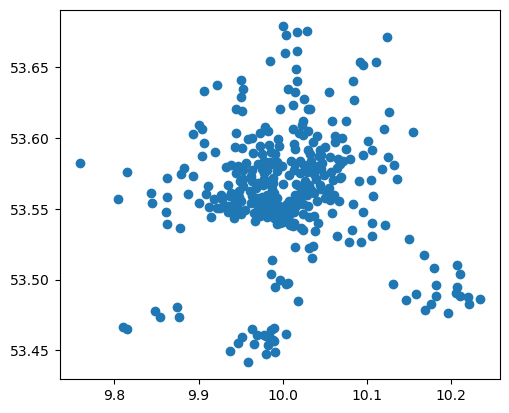

In [139]:
gdf_stadtrad.plot()
print(len(gdf_stadtrad))

In [140]:
gdf_stadtrad_barmbek = gpd.clip(
    gdf_stadtrad,
    barmbek_poly)

10


<Axes: >

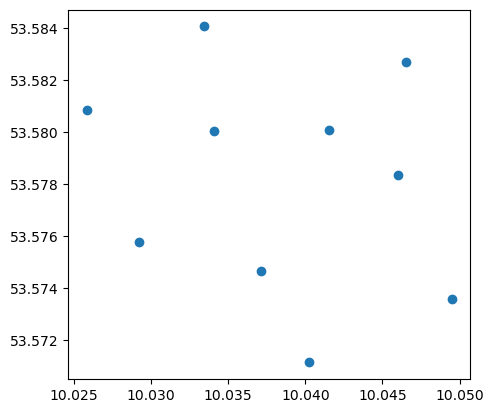

In [142]:
print(len(gdf_stadtrad_barmbek))
gdf_stadtrad_barmbek.plot()

In [141]:
gdf_stadtrad_barmbek.to_file(
    "../data/prep/prep_stadtrad_barmbek.geojson",
    driver="GeoJSON"
)

# Anerkannte ruhige Gebiete in Barmbek Süd

In [143]:
df_quiet = pd.read_csv(
    PATH_RAW + "raw_data_geoportal/de_hh_up_ruhige_gebiete_hamburg_EPSG_4326.csv",
    sep=";",
    engine="python"
)

In [144]:
print(df_quiet.columns)
df_quiet.head()

Index(['_fid', 'nr', 'ruhiges_gebiet', 'geom', 'coordinate_reference_system'], dtype='str')


,_fid,nr,ruhiges_gebiet,geom,coordinate_reference_system
0,DE.HH.UP_RUHIGE_GEBIETE_HAMBURG_91,1,Eißendorfer Forst,"MULTIPOLYGON (((9.924890 53.448131,9.924121 53...",EPSG:4326
1,DE.HH.UP_RUHIGE_GEBIETE_HAMBURG_92,2,Forst Sunder und Stuck,"MULTIPOLYGON (((9.926451 53.431432,9.925720 53...",EPSG:4326
2,DE.HH.UP_RUHIGE_GEBIETE_HAMBURG_93,3,Staatsforst Haake,"MULTIPOLYGON (((9.893965 53.471626,9.893425 53...",EPSG:4326
3,DE.HH.UP_RUHIGE_GEBIETE_HAMBURG_94,4,Neugrabener und Fischbeker Heide,"MULTIPOLYGON (((9.814637 53.462473,9.814902 53...",EPSG:4326
4,DE.HH.UP_RUHIGE_GEBIETE_HAMBURG_95,5,Schlickhügel Francop,"MULTIPOLYGON (((9.861572 53.516816,9.857743 53...",EPSG:4326


In [145]:
gdf_quiet = gpd.GeoDataFrame(
    df_quiet,
    geometry=gpd.GeoSeries.from_wkt(df_quiet["geom"]),
    crs="EPSG:4326"
)

<Axes: >

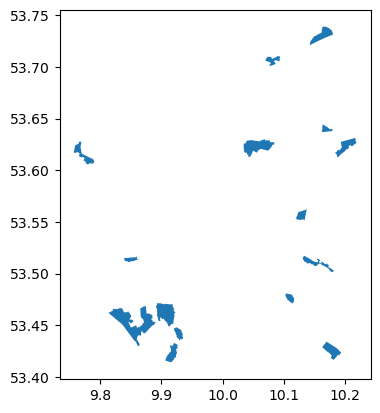

In [146]:
gdf_quiet.plot()

In [147]:
gdf_quiet_barmbek = gpd.clip(
    gdf_quiet,
    barmbek_poly)

0


ValueError: aspect must be finite and positive 

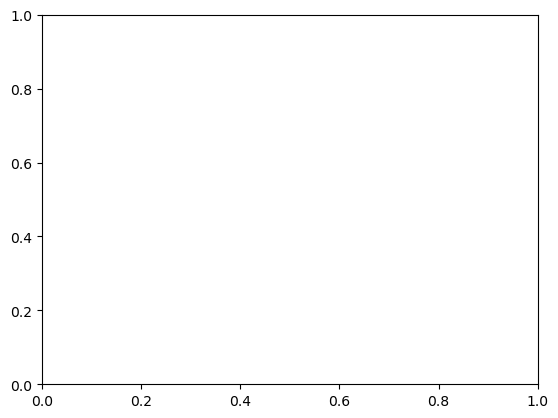

In [148]:
print(len(gdf_quiet_barmbek))
gdf_quiet_barmbek.plot()

In [149]:
print(len(gdf_quiet_barmbek))
print(gdf_quiet_barmbek.total_bounds)

0
[nan nan nan nan]


# No Quiet Places and Scooter in Barmbek Süd
“Within the study area of Barmbek-Süd, no designated e-scooter parking areas or recorded quiet zones were identified in the available datasets.”

“All datasets were spatially filtered to the study area. The absence of results indicates that these features are either not present or not captured in the available data.”

# Parks in Barmbek Süd

In [150]:
gdf_park = gpd.read_file(PATH_RAW + "raw_data_geoportal/bewohnerpark.geojson")

In [151]:
print(len(gdf_park))
gdf_park.head()

144


,_fid,objectid,bwp_name,bwp_code,geplant_aktiv,sonderbewirtschaftung,bemerkung,bewirtschaftungsart,bewirtschaftungszeit,hoechstparkdauer,gebuehrenzone,parkstaende,hinweis_intern,geom,coordinate_reference_system,geometry
0,DE.HH.UP_BEWOHNERPARKGEBIETE_28481,1,N 101 Flughafenstraße,N101,2,0,Stand 2019,"Parkscheibe, Bewohner mit Ausweis frei",täglich 9-20 Uhr,180,Parkscheibe,NaN,NaN,"MULTIPOLYGON (((10.014561 53.643272,10.015903 ...",EPSG:4326,"MULTIPOLYGON (((10.01456 53.64327, 10.0159 53...."
1,DE.HH.UP_BEWOHNERPARKGEBIETE_28482,2,N 100 Flughafen,N100,2,0,Stand 2006,"Parkscheibe, Bewohner mit Ausweis frei",täglich 9-20 Uhr,180,Parkscheibe,NaN,NaN,"MULTIPOLYGON (((10.013491 53.637756,10.013632 ...",EPSG:4326,"MULTIPOLYGON (((10.01349 53.63776, 10.01363 53..."
2,DE.HH.UP_BEWOHNERPARKGEBIETE_28483,3,N 103 Etzestraße,N103,2,0,Stand 2019,"Parkscheibe, Bewohner mit Ausweis frei",täglich 9-20 Uhr,180,Parkscheibe,NaN,NaN,"MULTIPOLYGON (((10.015948 53.634462,10.016282 ...",EPSG:4326,"MULTIPOLYGON (((10.01595 53.63446, 10.01628 53..."
3,DE.HH.UP_BEWOHNERPARKGEBIETE_28484,4,N 102 Bergkoppelweg,N102,2,0,Stand 2019,"Parkscheibe, Bewohner mit Ausweis frei",täglich 9-20 Uhr,180,Parkscheibe,NaN,NaN,"MULTIPOLYGON (((10.024171 53.634657,10.024481 ...",EPSG:4326,"MULTIPOLYGON (((10.02417 53.63466, 10.02448 53..."
4,DE.HH.UP_BEWOHNERPARKGEBIETE_28485,5,N 105 Ohlendörp,N105,2,0,Stand 2019,"Parkscheibe, Bewohner mit Ausweis frei",täglich 9-20 Uhr,180,Parkscheibe,NaN,NaN,"MULTIPOLYGON (((10.014063 53.627541,10.013994 ...",EPSG:4326,"MULTIPOLYGON (((10.01406 53.62754, 10.01399 53..."


In [152]:
print(gdf_park.crs)

EPSG:4326


<Axes: >

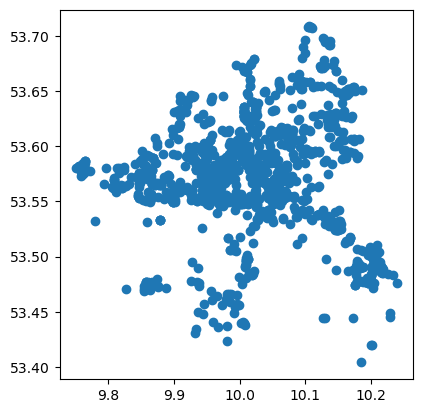

In [153]:
gdf_cross.plot()

In [154]:
gdf_park_barmbek = gpd.clip(
    gdf_park,
    barmbek_poly)

0


ValueError: aspect must be finite and positive 

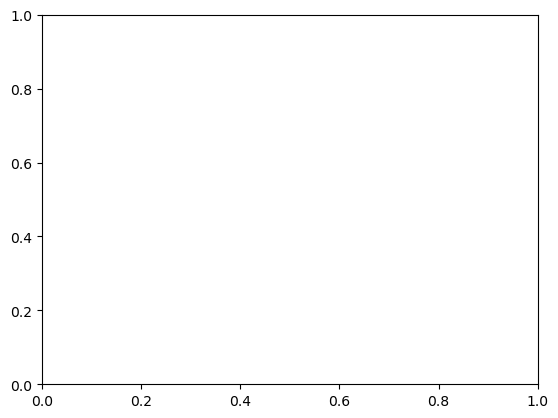

In [155]:
print(len(gdf_park_barmbek))
gdf_park_barmbek.plot()

In [ ]:
gdf_park_barmbek.to_file(
    "../data/prep/park_barmbek.geojson",
    driver="GeoJSON"
)

## "No park found in Barmbek-Süd."

# Eigene Busfahrstreifen in Barmbek Süd

In [156]:
df_bus = pd.read_csv(
    PATH_RAW + "raw_data_geoportal/de_hh_up_busfahrstreifen_EPSG_4326.csv",
    sep=";",
    engine="python"
)

In [157]:
print(len(df_bus))
df_bus.head()

412


,_fid,wnr_strassenname,rlagevst_beschreib,vst,bst,breite,leange,taxi,radfahrer,kommunaltrasse,wegeart,einrichtdat,bemerkung,vnk,nnk,geom,coordinate_reference_system
0,DE.HH.UP_BUSFAHRSTREIFEN_1,Adenauerallee,gesamte Fahrbahn(en) (ein- und zweibahnig),0,51,NaN,50.98,Ja,Nein,Nein,Stadtstraße,NaN,NaN,242617673,242617674,"LINESTRING (10.017805 53.552902,10.017918 53.5...",EPSG:4326
1,DE.HH.UP_BUSFAHRSTREIFEN_2,Adenauerallee,linker Fahrbahnrand (einbahnig),0,113,NaN,113.08,Ja,Nein,Nein,Stadtstraße,NaN,NaN,242613259,242600139,"LINESTRING (10.009853 53.552229,10.010169 53.5...",EPSG:4326
2,DE.HH.UP_BUSFAHRSTREIFEN_3,Alfred-Mahlau-Weg,rechte Fahrbahn (zweibahnig),13,127,3.5,106.46,Nein,Nein,Nein,Stadtstraße,1992.0,NaN,232616652,232616653,"LINESTRING (10.054140 53.608690,10.054137 53.6...",EPSG:4326
3,DE.HH.UP_BUSFAHRSTREIFEN_4,Alter Fischmarkt,rechter Fahrbahnrand (einbahnig),14,41,NaN,27.03,Ja,NaN,Nein,Stadtstraße,NaN,NaN,242500224,242500157,"LINESTRING (9.996847 53.548508,9.996846 53.548...",EPSG:4326
4,DE.HH.UP_BUSFAHRSTREIFEN_5,Alter Fischmarkt,rechter Fahrbahnrand (einbahnig),54,96,NaN,40.02,Ja,NaN,Nein,Stadtstraße,NaN,NaN,242500224,242500157,"LINESTRING (9.996721 53.548861,9.996720 53.548...",EPSG:4326


In [158]:
gdf_bus = gpd.GeoDataFrame(
    df_bus,
    geometry=gpd.GeoSeries.from_wkt(df_bus["geom"]),
    crs="EPSG:4326"
)

<Axes: >

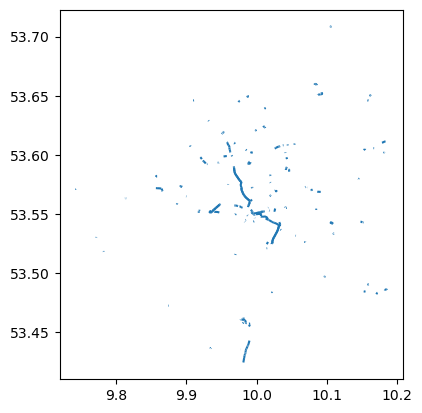

In [159]:
gdf_bus.plot()

In [160]:
gdf_bus_barmbek = gpd.clip(
    gdf_bus,
    barmbek_poly)

ValueError: aspect must be finite and positive 

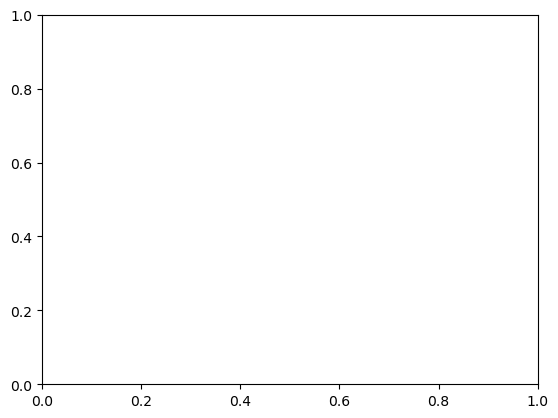

In [161]:
gdf_bus_barmbek.plot()

In [ ]:
print(len(gdf_bus_barmbek))
print(gdf_bus_barmbek.geom_type)

# “Buslane not found in the analysis of Barmbek-Süd, as accessibility is better represented by stop locations rather than route geometry and because Barmbek Süd has just one own buslane.”

# Innerstädtische Autobahnen

In [162]:
df_auto = pd.read_csv(
    PATH_RAW + "raw_data_geoportal/de_hh_up_autobahnen_EPSG_4326.csv",
    sep=";",
    engine="python"
)

In [163]:
print(df_auto.columns)
df_auto.head()

Index(['_fid', 'geom', 'coordinate_reference_system'], dtype='str')


,_fid,geom,coordinate_reference_system
0,DE.HH.UP_AUTOBAHNEN_0,"LINESTRING (9.897408 53.554558,9.897446 53.553...",EPSG:4326
1,DE.HH.UP_AUTOBAHNEN_1,"LINESTRING (11.619488 53.381390,11.619932 53.3...",EPSG:4326
2,DE.HH.UP_AUTOBAHNEN_2,"LINESTRING (9.915435 53.586674,9.915441 53.588...",EPSG:4326
3,DE.HH.UP_AUTOBAHNEN_3,"LINESTRING (9.915435 53.586674,9.915665 53.586...",EPSG:4326
4,DE.HH.UP_AUTOBAHNEN_4,"LINESTRING (9.916821 53.610844,9.917249 53.610...",EPSG:4326


In [164]:
gdf_auto = gpd.GeoDataFrame(
    df_auto,
    geometry=gpd.GeoSeries.from_wkt(df_auto["geom"]),
    crs="EPSG:4326"
)

<Axes: >

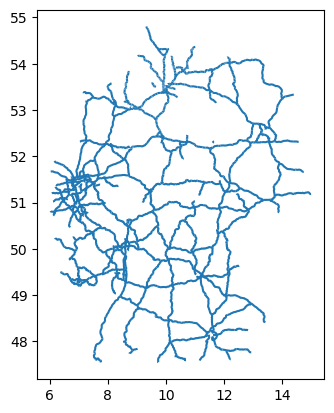

In [165]:
gdf_auto.plot()

In [166]:
gdf_auto_barmbek = gpd.clip(
    gdf_auto,
    barmbek_poly)

0


ValueError: aspect must be finite and positive 

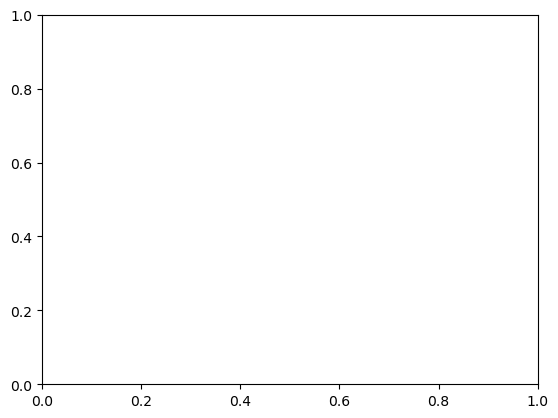

In [167]:
print(len(gdf_auto_barmbek))
gdf_auto_barmbek.plot()

In [ ]:
gdf_auto_barmbek.to_file(
    "../data/prep/highway_barmbek.geojson",
    driver="GeoJSON"
)

## "No highway found in Barmbek-Süd."

# Fußgängerüberwege

In [168]:
df_cross = pd.read_csv(
    PATH_RAW + "raw_data_geoportal/de_hh_up_fussgaengerueberwege_EPSG_4326.csv",
    sep=";",
    engine="python"
)

gdf_cross = gpd.GeoDataFrame(
    df_cross,
    geometry=gpd.GeoSeries.from_wkt(df_cross["geom"]),
    crs="EPSG:4326"
)

In [169]:
print(gdf_cross.crs)
print(barmbek_poly.crs)

EPSG:4326
EPSG:4326


In [170]:
gdf_cross_barmbek = gpd.clip(
    gdf_cross,
    barmbek_poly)

In [171]:
# unnötige Join-Spalten entfernen
gdf_cross_barmbek = gdf_cross_barmbek.drop(columns=["index_right"], errors="ignore")

# nur relevante Spalten behalten (optional, aber empfehlenswert)
gdf_cross_barmbek = gdf_cross_barmbek[[
    "bezeichnung",
    "strassenname",
    "geometry"
]]

15


<Axes: >

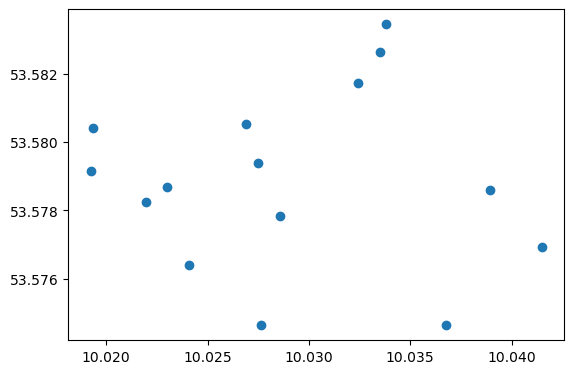

In [172]:
print(len(gdf_cross_barmbek))
gdf_cross_barmbek.plot()

In [173]:
gdf_cross_barmbek.to_file(
    "../data/prep/prep_fussgaengerueberwege_barmbek.geojson",
    driver="GeoJSON"
)

# Fahrradwege

In [174]:
gdf_bike = gpd.read_file(
    PATH_RAW + "raw_Masterportal-API/de_hh_up_radnetz_EPSG_4326.json"
)

In [175]:
gdf_bike_barmbek = gpd.clip(
    gdf_bike,
    barmbek_poly)

In [176]:
gdf_bike_barmbek_m = gdf_bike_barmbek.to_crs("EPSG:25832")

In [177]:
bike_length = gdf_bike_barmbek_m.length.sum()

print(bike_length)

12042.108363448788


In [178]:
bike_length_km = bike_length / 1000

print(bike_length_km)

12.042108363448788


In [185]:
gdf_bike_barmbek.head(20)

,id,laenge,status,geometry
672,DE.HH.UP_RADNETZ_678,25,Existing,"LINESTRING (10.03755 53.56996, 10.03768 53.57003)"
684,DE.HH.UP_RADNETZ_690,1015,Priority network improvements,"LINESTRING (10.05309 53.57392, 10.05265 53.574..."
342,DE.HH.UP_RADNETZ_343,712,Existing,"LINESTRING (10.02696 53.57036, 10.0271 53.5704..."
281,DE.HH.UP_RADNETZ_282,365,Existing,"LINESTRING (10.0371 53.5741, 10.0373 53.57393,..."
280,DE.HH.UP_RADNETZ_281,365,Existing,"LINESTRING (10.0371 53.5741, 10.0373 53.57393,..."
341,DE.HH.UP_RADNETZ_342,324,Existing,"LINESTRING (10.0363 53.57556, 10.03605 53.5754..."
636,DE.HH.UP_RADNETZ_640,177,Under construction,"LINESTRING (10.03325 53.57399, 10.03338 53.574..."
637,DE.HH.UP_RADNETZ_641,171,Under construction,"LINESTRING (10.03517 53.5751, 10.03536 53.5749..."
279,DE.HH.UP_RADNETZ_280,274,Existing,"LINESTRING (10.03143 53.57616, 10.03156 53.575..."
82,DE.HH.UP_RADNETZ_83,69,Existing,"LINESTRING (10.03605 53.57541, 10.03572 53.575..."


In [188]:
gdf_bike_barmbek["status"] = gdf_bike_barmbek["status"].replace({
    "Bestand": "Existing",
    "In Arbeit": "Under construction",
    "Priorisierte Netzergänzungen/Netzverbesserungen": "Priority network improvements",
    "Netzbedeutende Abschnitte mit Verbesserungspotential": "Sections with improvement potential"
})

In [189]:
gdf_bike_barmbek.to_file(
    "../data/prep/prep_bikelane_barmbek.geojson",
    driver="GeoJSON"
)

# Strassendeckschicht

In [240]:
df_streets_cover = pd.read_csv(PATH_RAW +  "raw_data_geoportal/de_hh_up_strassendeckschicht_EPSG_4326.csv",
    sep=";",
    engine="python"
)

gdf_streets_cover = gpd.GeoDataFrame(
    df_streets_cover,
    geometry=gpd.GeoSeries.from_wkt(df_streets_cover["geom"]),
    crs="EPSG:4326"
)
print(gdf_streets_cover.columns)
gdf_streets_cover.head()

Index(['_fid', 'von_netzknoten', 'nach_netzknoten', 'von_station',
       'bis_station', 'klasse', 'strassenschluessel', 'wegenummer',
       'strassenname', 'landesschluessel', 'kreisschluessel',
       'gemeindeschluessel', 'abschnittslaenge', 'ast', 'europastrasse',
       'fahrstreifenanzahl_in_stationierungsrichtung',
       'fahrstreifenanzahl_in_beide_richtungen',
       'fahrstreifenanzahl_gegen_stationierungsrichtung', 'bahnigkeit',
       'geschwindigkeit', 'wegeart', 'strassendeckschicht',
       'strassendeckschicht_kurz', 'geom', 'coordinate_reference_system',
       'geometry'],
      dtype='str')


,_fid,von_netzknoten,nach_netzknoten,von_station,bis_station,klasse,strassenschluessel,wegenummer,strassenname,landesschluessel,...,fahrstreifenanzahl_in_beide_richtungen,fahrstreifenanzahl_gegen_stationierungsrichtung,bahnigkeit,geschwindigkeit,wegeart,strassendeckschicht,strassendeckschicht_kurz,geom,coordinate_reference_system,geometry
0,DE.HH.UP_STRASSENDECKSCHICHT_184703,252600104,252700004,NaN,NaN,A,NaN,25 (8774),BAB A25,2,...,0,2,2,120 km/h,BAB - Betriebsstrecke,Nicht geriffelter Gussasphalt,MA,"LINESTRING (10.149426 53.480999,10.149575 53.4...",EPSG:4326,"LINESTRING (10.14943 53.481, 10.14958 53.48096)"
1,DE.HH.UP_STRASSENDECKSCHICHT_184704,242500004,242500009,NaN,NaN,A,B0756,7 (8777),BAB A7,2,...,0,3,2,NaN,BAB - Betriebsstrecke,"Offenporiger Asphalt (RLS-19, Tab. 4a, Zeile 6)",PA,"LINESTRING (9.915717 53.588529,9.915711 53.588...",EPSG:4326,"LINESTRING (9.91572 53.58853, 9.91571 53.58851)"
2,DE.HH.UP_STRASSENDECKSCHICHT_184705,242600019O,242600019S,NaN,NaN,A,NaN,1 (8778),BAB A1,2,...,0,0,1,60 km/h,BAB - Ast,Nicht geriffelter Gussasphalt,MA,"LINESTRING (10.080945 53.507176,10.080904 53.5...",EPSG:4326,"LINESTRING (10.08094 53.50718, 10.0809 53.5073..."
3,DE.HH.UP_STRASSENDECKSCHICHT_184706,252700005M,252700005N,NaN,NaN,A,NaN,25 (8774),BAB A25,2,...,0,0,1,100 km/h,BAB - Ast,"Offenporiger Asphalt (RLS-19, Tab. 4a, Zeile 6)",PA,"LINESTRING (10.205758 53.474389,10.205601 53.4...",EPSG:4326,"LINESTRING (10.20576 53.47439, 10.2056 53.47442)"
4,DE.HH.UP_STRASSENDECKSCHICHT_184707,252600101,252600008,NaN,NaN,A,NaN,1 (8778),BAB A1,2,...,0,3,2,Verkehrsbeeinflussungsanlage (variable Geschwi...,BAB - Betriebsstrecke,Nicht geriffelter Gussasphalt,MA,"LINESTRING (10.025719 53.462499,10.025796 53.4...",EPSG:4326,"LINESTRING (10.02572 53.4625, 10.0258 53.46223)"


In [247]:
gdf_streets_cover["strassendeckschicht"].unique()

<StringArray>
[                                                                                          'Nicht geriffelter Gussasphalt',
                                                                         'Offenporiger Asphalt (RLS-19, Tab. 4a, Zeile 6)',
              'Asphaltbetone ≤ AC 11 nach ZTV Asphalt-StB 07/13 und Abstumpfung mit Abstreumaterial der Lieferkörnung 1/3',
 'Splittmastixasphalte SMA5 und SMA8 nach ZTV Asphalt-StB 07/13 und Abstumpfung mit Abstreumaterial der Lieferkörnung 1/3',
                                                                             'Sonstiges Pflaster (RLS-19,Tab 4b, Zeile 2)']
Length: 5, dtype: str

37845


<Axes: >

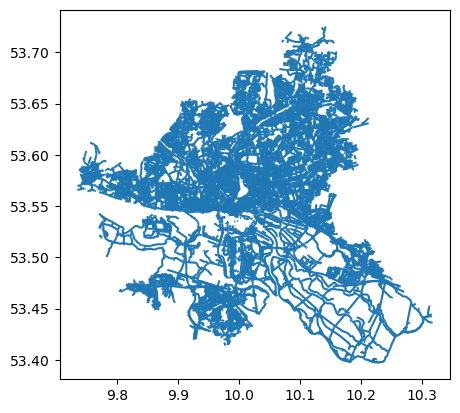

In [241]:
print(len(gdf_streets_cover))
gdf_streets_cover.plot()

In [242]:
gdf_streets_cover_barmbek = gpd.clip(gdf_streets_cover, barmbek_poly)

520


<Axes: >

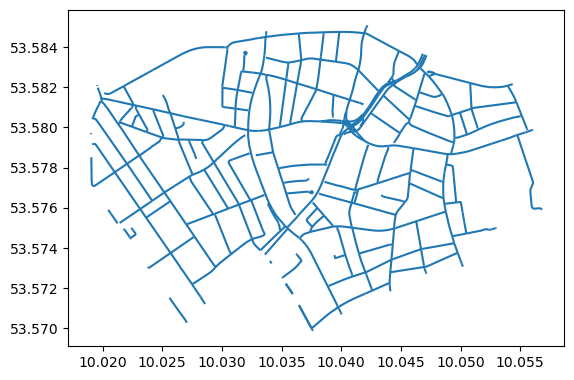

In [243]:
print(len(gdf_streets_cover_barmbek))
gdf_streets_cover_barmbek.plot()

In [244]:
print(len(gdf_streets_cover_barmbek))
print(gdf_streets_cover_barmbek.crs)

520
EPSG:4326


In [245]:
gdf_streets_cover_barmbek.to_file(
    "../data/prep/prep_streets_cover_barmbek.geojson",
    driver="GeoJSON"
)

# Grünflächen in Barmbek Süd

In [211]:
import geopandas as gpd

gdf_green = gpd.read_file(
    PATH_RAW + "raw_data_gruenflaechen/de_hh_up_gesamtstaedtische_gruenverbindung_EPSG_4326.json"
)

In [212]:
print(gdf_green.head())
print(gdf_green.crs)
print(gdf_green.geometry.type.value_counts())

                                                 id  \
0  DE.HH.UP_GESAMTSTAEDTISCHE_GRUENVERBINDUNG_54208   
1  DE.HH.UP_GESAMTSTAEDTISCHE_GRUENVERBINDUNG_54209   
2  DE.HH.UP_GESAMTSTAEDTISCHE_GRUENVERBINDUNG_54210   
3  DE.HH.UP_GESAMTSTAEDTISCHE_GRUENVERBINDUNG_54211   
4  DE.HH.UP_GESAMTSTAEDTISCHE_GRUENVERBINDUNG_54212   

               gruenverbindung  bezirk  \
0           Wollkämmerei (NEU)   Mitte   
1  Bahngrünzug Bahrenfeld NEU)  Altona   
2         Grünspange Stadtpark   Nord    
3                 Legienstraße   Mitte   
4              Walddörfer Bahn    Nord   

                                            geometry  
0  MULTILINESTRING ((9.98131 53.50116, 9.98744 53...  
1  MULTILINESTRING ((9.89819 53.5617, 9.89868 53....  
2  MULTILINESTRING ((9.99604 53.5977, 9.99455 53....  
3  MULTILINESTRING ((10.08737 53.55441, 10.08743 ...  
4  MULTILINESTRING ((10.05811 53.59369, 10.05805 ...  
EPSG:4326
MultiLineString    57
Name: count, dtype: int64


In [213]:
gdf_green_barmbek = gpd.clip(gdf_green, barmbek_poly)

3


<Axes: >

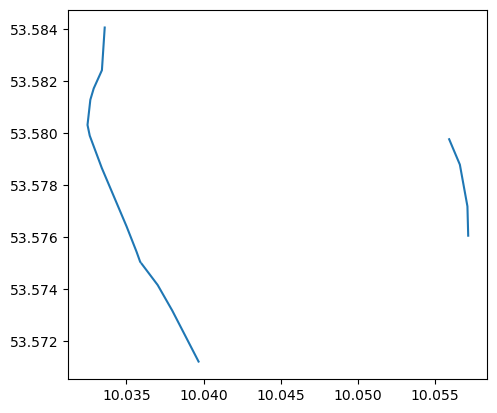

In [214]:
print(len(gdf_green_barmbek))
gdf_green_barmbek.plot()

In [ ]:
gdf_green_metric = gdf_green_barmbek.to_crs("EPSG:25832")

green_length_km = gdf_green_metric.length.sum() / 1000

print("Green network (km):", green_length_km)

In [ ]:
gdf_green_barmbek.to_file(
    "../data/prep/prep_green_barmbek.geojson",
    driver="GeoJSON"
)

## “Urban green corridors were extracted from city-wide datasets and spatially clipped to the study area to assess environmental walkability.”

# Digitaler Grünflächenplan Barmbek Süd

In [215]:
import geopandas as gpd

gdf_greenplan = gpd.read_file(
    PATH_RAW + "raw_data_gruenflaechen/Digitaler_Gruenplan_HH-2015-07-07.gml"
)

print(gdf_greenplan.head())
print(gdf_greenplan.columns)

                                   gml_id  OBJECTID  \
0  id62170475-d0e4-432d-a835-c335dd942adf         1   
1  idae455432-0bde-437f-9c88-d958c568798b         2   
2  id183f3663-95e3-415a-a3b4-9a46d12e0cb8         3   
3  id2c20f04f-a2c8-48d6-a4e2-9afaa147d7fd         4   
4  id82c41eac-732c-495b-9efe-c5576f852042         5   

                   QUELLE_DATEN IDENTNUMMER        ANLAGENTYP    DGPKEY  \
0  BSU, GEODATENSERVER (ArcSDE)      000001       Bezirkspark  10950033   
1  BSU, GEODATENSERVER (ArcSDE)      000002     Quartierspark  42850272   
2  BSU, GEODATENSERVER (ArcSDE)      000003  Allgemeines Grün  42850255   
3  BSU, GEODATENSERVER (ArcSDE)      000008     Quartierspark  51550099   
4  BSU, GEODATENSERVER (ArcSDE)      000009     Quartierspark  51550099   

                       GESAMTNAME  GESAMTNUMMER        ANLAGENNAME  \
0               Planten un Blomen        101002  Planten un Blomen   
1  Habichtsplatz - Schwalbenplatz        403013     Schwalbenplatz   
2       

In [216]:
import pyogrio

layers = pyogrio.list_layers(
    PATH_RAW + "raw_data_gruenflaechen/Digitaler_Gruenplan_HH-2015-07-07.gml"
)

print(layers)

[['Digitaler_Gruenplan' 'Unknown']]


In [217]:
gdf_greenplan = gpd.read_file(
    PATH_RAW + "raw_data_gruenflaechen/Digitaler_Gruenplan_HH-2015-07-07.gml",
    layer=layers[0][0]   # erster Layername
)

In [218]:
print(type(gdf_greenplan))

<class 'geopandas.geodataframe.GeoDataFrame'>


In [219]:
print(gdf_greenplan.columns)
print(gdf_greenplan.geometry.type.value_counts())

Index(['gml_id', 'OBJECTID', 'QUELLE_DATEN', 'IDENTNUMMER', 'ANLAGENTYP',
       'DGPKEY', 'GESAMTNAME', 'GESAMTNUMMER', 'ANLAGENNAME', 'BELEGENHEIT',
       'EIGENTUM', 'BEZIRKSNUMMER', 'ORTSTEIL', 'FLAECHE_QM', 'FLAECHE_HA',
       'GRUENART', 'NUTZCODE', 'STAND', 'Shape_Length', 'Shape_Area',
       'geometry'],
      dtype='str')
Polygon    4598
Name: count, dtype: int64


In [220]:
gdf_greenplan = gdf_greenplan.to_crs("EPSG:4326")

In [221]:
gdf_greenplan_barmbek = gpd.clip(gdf_greenplan, barmbek_poly)

In [222]:
print(gdf_greenplan.crs)
print(barmbek_poly.crs)

EPSG:4326
EPSG:4326


<Axes: >

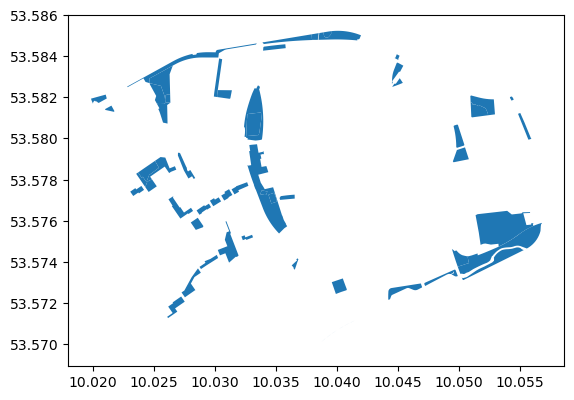

In [223]:
gdf_greenplan_barmbek.plot()

In [236]:
print(gdf_greenplan_barmbek["GRUENART"].unique())

<StringArray>
['Spielplatz', 'Parkanlage', 'Kleingarten', 'anderweitige Nutzung']
Length: 4, dtype: str


In [237]:
# =========================
# TRANSLATE (DE → EN)
# =========================
mapping = {
    "Spielplatz": "Playground",
    "Parkanlage": "Park",
    "Kleingarten": "Allotment garden",
    "anderweitige Nutzung": "Other use"
}

gdf_greenplan_barmbek["green_type"] = (
    gdf_greenplan_barmbek["GRUENART"]
    .map(mapping)
)

gdf_greenplan_barmbek = gdf_greenplan_barmbek.rename(columns={
    "NUTZCODE": "land_use_code"
})

# =========================
# FALLBACK (falls neue Werte)
# =========================
gdf_greenplan_barmbek["green_type"] = gdf_greenplan_barmbek["green_type"].fillna("Other")

# =========================
# OPTIONAL: ORIGINAL DROPPEN
# =========================
# gdf_greenplan_barmbek = gdf_greenplan_barmbek.drop(columns=["GRUENART"])

# =========================
# EXPORT
# =========================
gdf_greenplan_barmbek.to_file(
    "../data/prep/prep_greenplan_barmbek.geojson",
    driver="GeoJSON"
)

# =========================
# CHECK
# =========================
print(gdf_greenplan_barmbek[["GRUENART", "green_type"]].head())

        GRUENART  green_type
1376  Spielplatz  Playground
166   Parkanlage        Park
345   Parkanlage        Park
552   Spielplatz  Playground
682   Spielplatz  Playground


In [226]:
gdf_greenplan_barmbek.to_file(
 "../data/prep/prep_greenplan_barmbek.geojson",
    driver="GeoJSON"
)

# Street of Barmbek-Süd

In [ ]:
import geopandas as gpd

gdf_streets = gpd.read_file(PATH_RAW+ "raw_data_mobility/Strassen_und_Wegenetz_1.gml")

In [ ]:
import geopandas as gpd

gdf_streets_2 = gpd.read_file(PATH_RAW+ "raw_data_mobility/Strassen_und_Wegenetz_2.gml")

In [ ]:
print(gdf_streets.head())
print(gdf_streets.crs)
print(gdf_streets.geometry.type.value_counts())

In [ ]:
print(gdf_streets_2.head())
print(gdf_streets_2.crs)
print(gdf_streets_2.geometry.type.value_counts())

In [ ]:
gdf_streets = gdf_streets.to_crs("EPSG:4326")

In [ ]:
gdf_streets_2 = gdf_streets_2.to_crs("EPSG:4326")

In [ ]:
print(gdf_streets.crs)

In [ ]:
gdf_streets = gdf_streets[
    gdf_streets.geometry.type.isin(["LineString", "MultiLineString"])
]

In [ ]:
gdf_streets_2= gdf_streets_2[
    gdf_streets_2.geometry.type.isin(["LineString", "MultiLineString"])
]

In [ ]:
gdf_streets_barmbek = gpd.clip(gdf_streets, barmbek_poly)

In [ ]:
gdf_streets_2_barmbek = gpd.clip(gdf_streets_2, barmbek_poly)

In [ ]:
print(gdf_streets_barmbek.total_bounds)

In [ ]:
print(gdf_streets_2_barmbek.total_bounds)

In [ ]:
print(gdf_streets.crs)
print(gdf_streets_2.crs)
print(barmbek_poly.crs)

# Proof public stations with right coordinates!

In [ ]:
print(gdf_stations_hvv.crs)
print(barmbek_poly.crs)

In [ ]:
gdf_stations_hvv = gpd.GeoDataFrame(
    df_stations_hvv,
    geometry=gpd.points_from_xy(df_stations_hvv["lon"], df_stations_hvv["lat"]),
    crs="EPSG:4326"
)

In [ ]:
gdf_stations_hvv = gpd.GeoDataFrame(
    df_stations_hvv,
    geometry=gpd.points_from_xy(df_stations_hvv["lon"], df_stations_hvv["lat"]),
    crs="EPSG:25832"   # ❗ DAS IST DER WICHTIGE FIX
)

In [ ]:
gdf_stations_hvv = gdf_stations_hvv.to_crs("EPSG:4326")

In [ ]:
print(gdf_stations_hvv.total_bounds)

In [ ]:
gdf_stations_hvv.plot()

In [ ]:
df_old = pd.read_excel(
    PATH_RAW + "raw_data_mobility/hvv-haltestellen_hh_2013-08-22_10707_snap_1.xlsx",
    header=None
)

df_old.columns = ["name_full", "x", "y"]

In [ ]:
gdf_stations_hvv = gdf_stations_hvv.to_crs("EPSG:4326")

In [ ]:
gdf_stations_hvv = gdf_stations_hvv.to_crs("EPSG:4326")

In [ ]:
gdf_stations_hvv_barmbek = gpd.clip(
    gdf_stations_hvv,
    barmbek_poly
)

In [ ]:
print(gdf_stations_hvv.columns)

In [ ]:
gdf_stations_hvv.head()

In [ ]:
gdf_stations_hvv["type"] = gdf_stations_hvv["name"].str.extract(r"^([A-Z])")

In [ ]:
gdf_stations_hvv["name_clean"] = gdf_stations_hvv["name"].str.replace(
    r"^[A-Z]\s+", "", regex=True
)

In [ ]:
gdf_stations_hvv = gdf_stations_hvv[[
    "name_clean",
    "type",
    "lon",
    "lat",
    "geometry"
]]

In [ ]:
gdf_stations_hvv.head()

In [ ]:
print(gdf_stations_hvv.total_bounds)

In [ ]:
df_new = pd.read_excel(
    PATH_RAW + "raw_data_mobility/HVV-Haltestellen.xlsx",
    header=None
)
df_new.columns = ["name", "lon", "lat"]

df_old = pd.read_excel(
    PATH_RAW + "raw_data_mobility/hvv-haltestellen_hh_2013-08-22_10707_snap_1.xlsx",
    header=None
)
df_old.columns = ["name_full", "x", "y"]

In [ ]:
df_old["name_clean"] = df_old["name_full"].str.replace(
    r"^[A-Z]\s+", "", regex=True
)

In [ ]:
df_old[["name_full", "name_clean"]].head()

In [ ]:
df_merged = df_new.merge(
    df_old[["name_full", "name_clean"]],
    left_on="name",
    right_on="name_clean",
    how="left"
)

In [ ]:
df_merged.head()

In [ ]:
df_merged["type"] = df_merged["name_full"].str.extract(r"^([A-Z])")

In [ ]:
df_merged = df_merged[
    df_merged["name_full"].str.match(r"^[USA]\s", na=False)
]

In [ ]:
df_merged["type"] = df_merged["name_full"].str.extract(r"^([USA])")

In [ ]:
df_merged = df_merged.drop_duplicates(subset=["name", "type"])

In [ ]:
df_merged.head()

In [ ]:
gdf_stations = gpd.GeoDataFrame(
    df_merged,
    geometry=gpd.points_from_xy(df_merged["lon"], df_merged["lat"]),
    crs="EPSG:4326"
)

In [ ]:
gdf_stations.head()

In [ ]:
gdf_stations_barmbek = gpd.clip(
    gdf_stations,
    barmbek_poly
)

print(len(gdf_stations_barmbek))

In [ ]:
print(gdf_stations_barmbek.total_bounds)

In [ ]:
print(len(gdf_stations))

In [ ]:
print("Stations CRS:", gdf_stations.crs)
print("Barmbek CRS:", barmbek_poly.crs)

print("Stations bounds:", gdf_stations.total_bounds)
print("Barmbek bounds:", barmbek_poly.total_bounds)

In [ ]:
gdf_stations_barmbek.to_file(
    "../data/prep/hvv_stations_barmbek.geojson",
    driver="GeoJSON"
)

In [ ]:
print(gdf_stations_barmbek.crs)

In [ ]:
gpd.read_file("../data/prep/hvv_stations_barmbek.geojson").head()

In [ ]:
print(len(gdf_stations_barmbek))

In [ ]:
gdf_stations.plot()
barmbek_poly.plot(ax=plt.gca(), edgecolor="red", facecolor="none")

In [ ]:
gdf_bike = gpd.read_file(
    PATH_RAW + "raw_Masterportal-API/de_hh_up_radnetz_EPSG_4326.json"
)

print(gdf_bike.crs)

In [ ]:
gdf_bike_barmbek = gpd.clip(
    gdf_bike,
    barmbek_poly
)

In [ ]:
print(gdf_bike_barmbek.total_bounds)

In [ ]:
gdf_bike_barmbek_m = gdf_bike_barmbek.to_crs("EPSG:25832")

bike_length_km = gdf_bike_barmbek_m.length.sum() / 1000
print(bike_length_km)

In [ ]:
print(barmbek_poly.is_valid)

In [ ]:
print(barmbek_poly.total_bounds)

# “Public transport accessibility was measured based on unique stop locations, independent of the number of lines serving each stop.”

In [ ]:
df_barmbek = pd.read_csv(PATH_RAW +
    "raw_data_mobility/public_transport_barmbek_sued.csv",
    sep=";"
)

In [ ]:
df_barmbek.head

In [ ]:
gdf_stations.head()

In [ ]:
df_barmbek["name"] = df_barmbek["Haltestelle"].str.strip()

In [ ]:
df_merged = df_barmbek.merge(
    gdf_stations[["name", "geometry", "type"]],
    on="name",
    how="left"
)

In [ ]:
print(df_merged[df_merged["geometry"].isna()])

In [ ]:
print(df_barmbek["Haltestelle"].unique())
print(gdf_stations["name"].unique())

In [ ]:
for name in df_barmbek["Haltestelle"].unique():
    if name not in gdf_stations["name"].values:
        print("NOT FOUND:", repr(name))

In [ ]:
gdf_stations[gdf_stations["name"] == "Barmbek"]

In [ ]:
gdf_stations[gdf_stations["name"].str.contains("Barmbek", case=False, na=False)]

In [ ]:
for x in gdf_stations["name"]:
    if "Barmbek" in str(x):
        print(repr(x))

In [ ]:
print(len(gdf_stations[gdf_stations["name"].str.contains("Barmbek", case=False, na=False)]))

In [ ]:
def find_geometry(name):
    matches = gdf_stations[
        gdf_stations["name"].str.contains(name, case=False, na=False)
    ]
    if len(matches) > 0:
        return matches.iloc[0]["geometry"]
    return None

df_barmbek["geometry"] = df_barmbek["Haltestelle"].apply(find_geometry)

In [ ]:
print(df_barmbek[["Haltestelle", "geometry"]])

# Hat so nicht geklappt, da Daten keine richtigen Koordinaten

# Erneute Prüfung Haltestellen

“The dataset includes the entire HVV region, therefore a spatial filter was applied to restrict the analysis to Hamburg.”

In [ ]:
import pandas as pd
import geopandas as gpd

df_haltestellen_new = pd.read_excel(
    PATH_RAW+ "raw_data_mobility/HVV-Haltestellen_metaver.xlsx",
    header=None
)

df_haltestellen_new.columns = ["name", "lon", "lat"]

In [ ]:
df_haltestellen_new = df_haltestellen_new[
    (df_haltestellen_new["lon"] > 9.8) &
    (df_haltestellen_new["lon"] < 10.1) &
    (df_haltestellen_new["lat"] > 53.5) &
    (df_haltestellen_new["lat"] < 53.65)
]

In [ ]:
print(df_haltestellen_new.head())
print(df_haltestellen_new.dtypes)

In [ ]:
df_haltestellen_new["name_clean"] = df_haltestellen_new["name"]

# Präfix entfernen
df_haltestellen_new["name_clean"] = df_haltestellen_new["name_clean"].str.replace(r"^[A-Z]\s+", "", regex=True)

# Klammern entfernen
df_haltestellen_new["name_clean"] = df_haltestellen_new["name_clean"].str.replace(r"\(.*?\)", "", regex=True)

# Komma abschneiden
df_haltestellen_new["name_clean"] = df_haltestellen_new["name_clean"].str.split(",").str[0]

# final clean
df_haltestellen_new["name_clean"] = (
    df_haltestellen_new["name_clean"]
    .str.strip()
    .str.lower()
)

In [ ]:
df_barmbek_haltestellen= pd.read_csv(PATH_RAW + 
    "raw_data_mobility/public_transport_barmbek_sued.csv",
    sep=";"
)

In [ ]:
df_barmbek_haltestellen["name_clean"] = (
    df_barmbek_haltestellen["Haltestelle"]
    .str.strip()
    .str.lower()
)

In [ ]:
mapping = {
    "u mundsburg": "mundsburg",
    "mundsburger brücke": "mundsburg"
}

df_barmbek_haltestellen["name_clean"] = df_barmbek_haltestellen["name_clean"].replace(mapping)

In [ ]:
df_merged_haltestellen = df_barmbek_haltestellen.merge(
    df_haltestellen_new,
    on="name_clean",
    how="left"
)

In [ ]:
df_merged_haltestellen.head()

# Zwischendurch Ergebnis für einzelne Zählung der Verkehrsmittel

In [ ]:
# 1. Deduplicate (wichtig!)
df_unique = df_merged_haltestellen.drop_duplicates(
    subset=["Verkehrsmittel", "Haltestelle"]
)

# 2. GeoDataFrame
gdf_temp = gpd.GeoDataFrame(
    df_unique,
    geometry=gpd.points_from_xy(df_unique["lon"], df_unique["lat"]),
    crs="EPSG:4326"
)

# 3. CRS match
gdf_temp = gdf_temp.to_crs(barmbek_poly.crs)

# 4. Clip
gdf_clipped = gpd.clip(gdf_temp, barmbek_poly)

# 5. Count
result = gdf_clipped.groupby("Verkehrsmittel").size()

print(result)

## Weiterführung von merge der beiden Tabellen

In [ ]:
df_merged_haltestellen["bus"] = (df_merged_haltestellen["Verkehrsmittel"] == "Bus").astype(int)
df_merged_haltestellen["u_bahn"] = (df_merged_haltestellen["Verkehrsmittel"] == "U-Bahn").astype(int)
df_merged_haltestellen["s_bahn"] = (df_merged_haltestellen["Verkehrsmittel"] == "S-Bahn").astype(int)

In [ ]:
df_grouped = df_merged_haltestellen.groupby("name").agg({
    "lon": "first",
    "lat": "first",
    
    "bus": "max",
    "u_bahn": "max",
    "s_bahn": "max",
    
    "Linie": lambda x: list(x),
    "Verkehrsmittel": lambda x: list(x)
}).reset_index()

In [ ]:
def extract_lines(row, mode):
    return ", ".join(sorted(set([
        l for l, m in zip(row["Linie"], row["Verkehrsmittel"]) if m == mode
    ])))

df_grouped["U-Bahn"] = df_grouped.apply(lambda row: extract_lines(row, "U-Bahn"), axis=1)
df_grouped["S-Bahn"] = df_grouped.apply(lambda row: extract_lines(row, "S-Bahn"), axis=1)
df_grouped["Bus"] = df_grouped.apply(lambda row: extract_lines(row, "Bus"), axis=1)

In [ ]:
df_grouped = df_grouped.drop(columns=["Linie", "Verkehrsmittel"])

In [ ]:
import geopandas as gpd

gdf_final_stations = gpd.GeoDataFrame(
    df_grouped,
    geometry=gpd.points_from_xy(df_grouped["lon"], df_grouped["lat"]),
    crs="EPSG:4326"
)

In [ ]:
gdf_final_stations_barmbek = gpd.clip(gdf_final_stations, barmbek_poly)

In [ ]:
gdf_final_stations_barmbek.head(20)

In [ ]:
gdf_final_stations_barmbek.to_file(
    "../data/prep/prep_public_transport_barmbek.geojson",
    driver="GeoJSON"
)

In [ ]:
print(gdf_final_stations_barmbek["geometry"].isna().sum())

In [ ]:
print(gdf_final_stations_barmbek.head())

# Haltestellen für map mit Spalte Verkehrsmittel

In [ ]:
import pandas as pd
import geopandas as gpd

# =========================
# 1. COPY
# =========================
gdf_map = gdf_final_stations_barmbek.copy()

# =========================
# 2. LONG FORMAT ERSTELLEN
# =========================

# Bus-Daten
df_bus = gdf_map[gdf_map["bus"] == 1].copy()
df_bus["Verkehrsmittel"] = "Bus"
df_bus["Linien"] = df_bus["Bus"]

# U-Bahn Daten
df_ubahn = gdf_map[gdf_map["u_bahn"] == 1].copy()
df_ubahn["Verkehrsmittel"] = "U-Bahn"
df_ubahn["Linien"] = df_ubahn["U-Bahn"]

# (optional S-Bahn falls vorhanden)
df_sbahn = gdf_map[gdf_map["s_bahn"] == 1].copy()
df_sbahn["Verkehrsmittel"] = "S-Bahn"
df_sbahn["Linien"] = df_sbahn["S-Bahn"]

# =========================
# 3. ZUSAMMENFÜHREN
# =========================
gdf_long = pd.concat([df_bus, df_ubahn, df_sbahn], ignore_index=True)

# =========================
# 3.5 AGGREGATION (WICHTIG!)
# =========================
gdf_long = gdf_long.groupby(["name", "Verkehrsmittel", "geometry"]).agg({
    "Linien": lambda x: ", ".join(sorted(set(x.dropna().astype(str))))
}).reset_index()

# =========================
# 4. NUR RELEVANTE SPALTEN
# =========================
gdf_long = gdf_long[[
    "name",
    "Verkehrsmittel",
    "Linien",
    "geometry"
]]

# =========================
# 5. CRS + CLIP
# =========================
gdf_long = gdf_long.set_geometry("geometry")
gdf_long = gdf_long.to_crs(barmbek_poly.crs)
gdf_long = gpd.clip(gdf_long, barmbek_poly)

# =========================
# 6. EXPORT
# =========================
gdf_long.to_file(
    "../data/prep/prep_stations_with_mode.geojson",
    driver="GeoJSON"
)

# =========================
# 7. CHECK
# =========================
print(gdf_long.head())

## Haltestellen als Linien

In [ ]:
import pandas as pd
import re

# =========================
# 1. COPY
# =========================
df_temp = df_merged_haltestellen.copy()

# =========================
# 2. CLEAN
# =========================
df_temp["Verkehrsmittel"] = df_temp["Verkehrsmittel"].str.strip()
df_temp["Linie"] = df_temp["Linie"].astype(str).str.upper().str.strip()

# =========================
# 3. SPLIT + EXPLODE
# =========================
df_temp["Linie"] = df_temp["Linie"].str.split(",")
df_temp = df_temp.explode("Linie")
df_temp["Linie"] = df_temp["Linie"].str.strip()

# =========================
# 4. REMOVE DUPLICATES
# =========================
df_lines = df_temp.drop_duplicates(subset=["Verkehrsmittel", "Linie"])

# =========================
# 5. SORTIERFUNKTION
# =========================
def sort_lines_desc(lines):
    def extract_number(x):
        match = re.search(r"\d+", x)
        return int(match.group()) if match else -1
    
    return ", ".join(
        sorted(lines, key=lambda x: extract_number(x), reverse=True)
    )

# =========================
# 6. LISTE ERSTELLEN
# =========================
df_lines_list = (
    df_lines.groupby("Verkehrsmittel")["Linie"]
    .apply(lambda x: sort_lines_desc(x))
    .reset_index()
)

print(df_lines_list)

# =========================
# 7. EXPORT
# =========================
df_lines_list.to_csv(
    "../data/mart/mart_public_lines_list.csv",
    index=False,
    sep=";",
    encoding="utf-8"
)

# ALLE DATEN ZUSAMMEN IN KARTE

## "All datasets were spatially clipped to the study area to ensure consistency and avoid including features outside the defined boundary.”

In [ ]:
import geopandas as gpd

gdf_stops = gpd.read_file("../data/prep/prep_public_transport_barmbek.geojson")
gdf_bikelane = gpd.read_file("../data/prep/prep_bikelane_barmbek.geojson")
gdf_citybike = gpd.read_file ("../data/prep/prep_stadtrad_barmbek.geojson")
gdf_crossings = gpd.read_file("../data/prep/prep_crossings_barmbek.geojson")
gdf_greens = gpd.read_file("../data/prep/prep_greenplan_barmbek.geojson")

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))

# Grünflächen (unten)
gdf_greens.plot(ax=ax, color="lightgreen", alpha=0.5)

# Bike lanes (Linien)
gdf_bikelane.plot(ax=ax, color="blue", linewidth=1)

# Stadtrad (Punkte)
gdf_citybike.plot(ax=ax, color="cyan", markersize=20)

# Crossings
gdf_crossings.plot(ax=ax, color="red", markersize=15)

# Stops (oben)
gdf_stops.plot(ax=ax, color="black", markersize=30)

plt.title("Walkability Components – Barmbek-Süd")
plt.savefig("walkability_barmbek_sued.png", dpi=300, bbox_inches="tight")
plt.axis("off")

In [ ]:
fig, ax = plt.subplots(figsize=(10,10))

# Fläche
barmbek_poly.plot(ax=ax, color="none", edgecolor="black", linewidth=2)

# Grünflächen
gdf_green.plot(ax=ax, color="lightgreen", alpha=0.5)

# Straßen
df_streets_cover.plot(ax=ax, color="blue", linewidth=1)

# Punkte
gdf_final_stations.plot(ax=ax, color="red", markersize=25, label="Public Transport")
gdf_citybike.plot(ax=ax, color="cyan", markersize=25, label="City Bike")
gdf_crossings.plot(ax=ax, color="black", markersize=25, label="Crossings")

# Layout
ax.set_title("Walkability Components – Barmbek-Süd", fontsize=14)
ax.legend()
ax.set_axis_off()

# WALKABILITY TEST

In [ ]:
walkability = {
    "pt_stops": len(gdf_final_stations),
    "crossings": len(gdf_cross_barmbek),
    "bike_km": bike_length_km
}

print(walkability)

# Einwohnerdaten Barmbek Süd

In [ ]:
df_profile_barmbek_sued = pd.read_excel("../data/raw/raw_data_population/ueberarbeitet_Stadtteilprofile Barmbek_Sued-Berichtsjahre-2013-2023.xlsx")

In [ ]:
print(df_profile_barmbek_sued.head())
print(df_profile_barmbek_sued.columns)
print(df_profile_barmbek_sued.info())

In [ ]:
df_profile_barmbek_sued.columns = [
    f"{col1}_{col2}" if col2 else col1
    for col1, col2 in df_profile_barmbek_sued.columns
]

In [ ]:
df_profile_barmbek_sued.columns = (
    df_profile_barmbek_sued.columns
    .str.lower()
    .str.replace(" ", "_")
)

In [ ]:
df_long = df_profile_barmbek_sued.melt(
    id_vars=["indikator"],  # ggf. anpassen!
    var_name="variable",
    value_name="value"
)

In [ ]:
df_long["year"] = pd.to_numeric(df_long["year"], errors="coerce")
df_long["value"] = pd.to_numeric(df_long["value"], errors="coerce")

# Income and housing

In [203]:
import pandas as pd

df_income = pd.read_excel(
    "../data/raw/raw_data_population/Stadtteilprofile2024.xlsx",
    header=[0,1]
)

In [204]:
df_income.columns = [
    "_".join([str(c) for c in col if c])
    for col in df.columns
]

In [205]:
df_income = df_income.rename(columns={
    "Stadtgebiet_Unnamed: 0_level_1": "district",
    "Sozialstruktur_Einkommen je Steuer-pflichtigen in Euro (2021)": "income"
})

In [206]:
df_income.columns = df_income.columns.str.replace("_", "")

In [207]:
print(df_income.columns)

Index(['StadtgebietUnnamed: 0level1',
       'Bevölkerung und Haushalte 31.12.2024Bevölkerung',
       'Bevölkerung und Haushalte 31.12.2024Unter 18-Jährige',
       'Bevölkerung und Haushalte 31.12.2024Anteil der unter 18-Jährigen in %',
       'Bevölkerung und Haushalte 31.12.2024 65-Jährige und Ältere',
       'Bevölkerung und Haushalte 31.12.2024Anteil der 65-Jährigen und Älteren in %',
       'Bevölkerung und Haushalte 31.12.2024Ausländer: innen',
       'Bevölkerung und Haushalte 31.12.2024Anteil der Ausländer: innen in %',
       'Bevölkerung und Haushalte 31.12.2024Bevölkerung mit Migrations-hintergrund',
       'Bevölkerung und Haushalte 31.12.2024Anteil der Bevölkerung mit Migrations-hintergrund in %',
       'Bevölkerung und Haushalte 31.12.2024Unter 18-Jährige mit Migrations-hintergrund',
       'Bevölkerung und Haushalte 31.12.2024Anteil der unter 18-Jährigen mit Migrations-hintergrund in %',
       'Bevölkerung und Haushalte 31.12.2024Haushalte',
       'Bevölkerung und H

In [210]:
import pandas as pd

df_compare = df.copy()

# =========================
# AUTO-DETECT COLUMNS
# =========================
district_col = [col for col in df_compare.columns if "Stadtgebiet" in col][0]
income_col = [col for col in df_compare.columns if "Einkommen je Steuer" in col][0]
housing_col = [col for col in df_compare.columns if "Sozial-wohnungs-anteil" in col][0]

# =========================
# RENAME
# =========================
df_compare = df_compare.rename(columns={
    district_col: "district",
    income_col: "income",
    housing_col: "social_housing_pct"
})

# =========================
# FILTER
# =========================
df_compare = df_compare[
    df_compare["district"].isin(["Barmbek-Süd", "Harvestehude"])
]

# =========================
# SELECT
# =========================
df_compare = df_compare[[
    "district",
    "income",
    "social_housing_pct"
]]

# =========================
# CLEAN
# =========================
df_compare["income"] = (
    df_compare["income"]
    .astype(str)
    .str.replace(".", "", regex=False)
    .str.replace(",", ".", regex=False)
    .astype(float)
)

df_compare["social_housing_pct"] = (
    df_compare["social_housing_pct"]
    .astype(str)
    .str.replace(",", ".")
    .astype(float)
)

# =========================
# LONG FORMAT
# =========================
df_compare_long = df_compare.melt(
    id_vars=["district"],
    var_name="indicator",
    value_name="value"
)

# =========================
# YEAR
# =========================
df_compare_long["year"] = df_compare_long["indicator"].map({
    "income": 2021,
    "social_housing_pct": 2024
})

# =========================
# LABELS
# =========================
df_compare_long["indicator"] = df_compare_long["indicator"].replace({
    "income": "Income per taxpayer",
    "social_housing_pct": "Social housing (%)"
})

# =========================
# EXPORT
# =========================
df_compare_long.to_csv(
    "../data/mart/mart_income_compare.csv",
    index=False
)

print(df_compare_long)

       district            indicator     value  year
0  Harvestehude  Income per taxpayer  120835.0  2021
1   Barmbek-Süd  Income per taxpayer   44577.0  2021
2  Harvestehude   Social housing (%)       0.2  2024
3   Barmbek-Süd   Social housing (%)       5.4  2024
